# 🌐 Applications of Machine Learning

> *Machine Learning is already embedded in most of the apps you use daily — often so seamlessly that you never notice it's there.*

## 🎯 Introduction

Machine Learning (ML) is already deeply integrated into many of the products people use every day — Facebook, YouTube, Amazon — often completely unnoticed by the people using them. Across industries, ML is revolutionizing how work gets done: automating complex tasks, improving predictions, and providing data-driven insights that were previously impossible to extract at scale.

This note walks through ML's role across several major sectors, and also looks at how ML spans both **B2B** (Business-to-Business) and **B2C** (Business-to-Consumer) use cases — helping companies optimize operations, cut costs, and increase profits.

## 🗺️ Overview Map

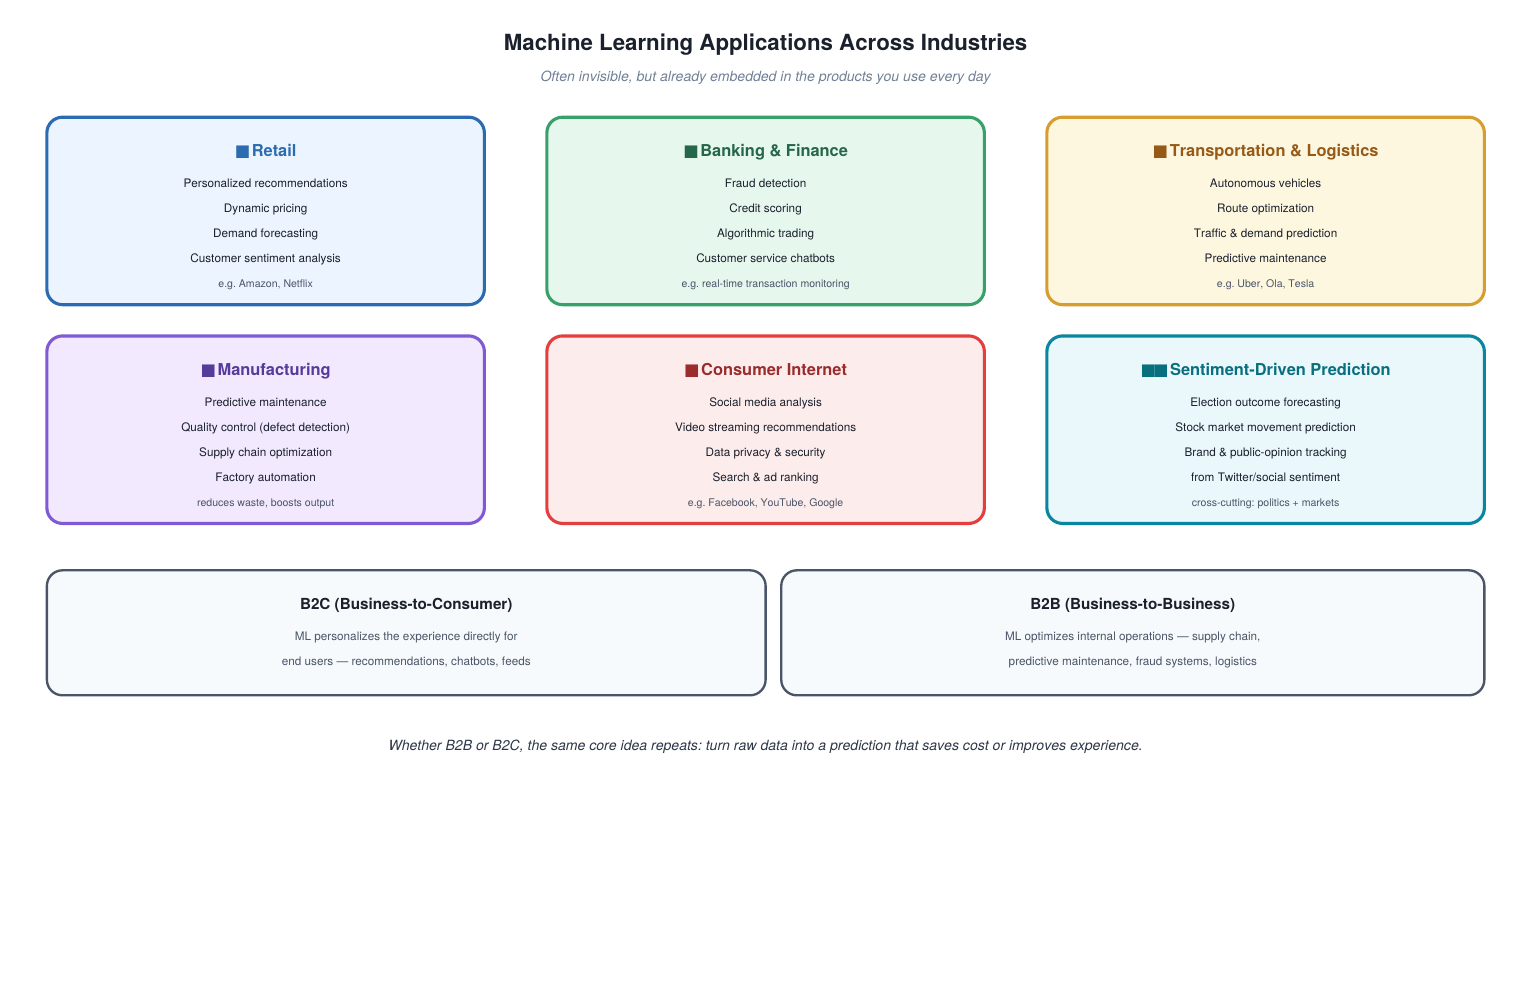

- **B2C (Business-to-Consumer):** ML personalizes the experience directly for end users — think recommendations, chatbots, and content feeds.
- **B2B (Business-to-Business):** ML optimizes internal operations — supply chains, predictive maintenance, fraud detection systems, and logistics.

Whether it's B2B or B2C, the same core idea repeats across every sector below: turn raw data into a prediction that either saves cost or improves experience.

## 1️⃣ Retail Sector

In retail, machine learning is used to optimize the customer experience, inventory management, and personalized marketing. Key applications include:

- **Personalized Recommendations:** Retailers like Amazon and Netflix use ML algorithms to analyze customer behavior and recommend products or movies based on past purchases/viewing history.
- **Dynamic Pricing:** Retailers use ML models to set prices by analyzing market conditions, customer preferences, and competitor pricing strategies.
- **Demand Forecasting:** ML models predict product demand, so retailers can stock the right quantity and reduce inventory costs.
- **Customer Sentiment Analysis:** Customer reviews and feedback are analyzed to gauge customer sentiment, helping businesses improve their products or services.

## 2️⃣ Banking and Finance

Machine learning plays a critical role in decision-making, fraud detection, and financial portfolio optimization in the banking and finance sector.

- **Fraud Detection:** ML models detect unusual patterns in transactions, helping identify fraudulent activity in real time.
- **Credit Scoring:** ML algorithms analyze a person's financial history and other factors to assess their creditworthiness.
- **Algorithmic Trading:** ML models analyze market data and execute trades at optimal times, helping increase profit and reduce risk.
- **Customer Service Chatbots:** ML-powered chatbots can answer customers' routine questions, reducing wait times and improving service quality.

## 3️⃣ Transportation & Logistics Sector

In transportation, machine learning is used in autonomous vehicles, route optimization, and predictive maintenance.

- **Autonomous Vehicles:** ML technology is essential for self-driving cars — models help vehicles recognize objects, plan routes, and make real-time decisions. **Tesla** is a well-known example of ML-driven autonomous vehicle systems.
- **Route Optimization:** ML algorithms optimize delivery routes, reducing fuel costs and improving delivery times.
- **Traffic Prediction:** ML models analyze traffic data to predict jams, so drivers can take alternate routes and avoid delays.
- **Predictive Maintenance:** ML models predict vehicle maintenance needs, keeping transportation systems running smoothly and reducing downtime.
- **Ride-Hailing Demand-Supply Balancing:** Companies like **Uber** and **Ola** use ML to predict rider demand across areas and times, and use this to balance driver supply and set dynamic ("surge") pricing — directly improving service quality and operational efficiency.

## 4️⃣ Manufacturing Sector

In manufacturing, machine learning is used to ensure smooth production processes, supply chain optimization, and quality control.

- **Predictive Maintenance:** ML models predict machine failures ahead of time, enabling proactive maintenance — this reduces production costs and increases production capacity.
- **Quality Control:** ML models identify product defects during the production process, ensuring quality and reducing waste.
- **Supply Chain Optimization:** ML algorithms analyze the supply chain to enable faster and more efficient product distribution.
- **Factory Automation:** Beyond individual tasks, ML is driving broader automation across entire factory floors — combining predictive analytics with automated decision-making to boost overall productivity.

## 5️⃣ Consumer Internet Sector

In the consumer internet sector, machine learning is especially used in social media, video streaming, and understanding customer preferences.

- **Social Media Analysis:** ML is used on social media platforms to analyze customer interests, behavior, and sentiment, helping businesses improve their content strategy.
- **Video Streaming Services:** Platforms like Netflix and YouTube use ML algorithms to recommend videos based on viewers' past experience.
- **Data Privacy and Security:** ML is used to help ensure the security of customer data, limiting unwanted or harmful access.
- **Platform Evolution:** Internet-based companies like Google and Twitter (X) have evolved significantly by embedding ML deeper into search, ad ranking, and content moderation — showing how ML drives both innovation and profitability over time.

## 6️⃣ Sentiment Analysis for Political & Market Predictions

A particularly striking cross-cutting application: analyzing sentiment from social media (like Twitter/X) can be used to **forecast election results** and **predict stock market movements**. By processing large volumes of public posts and scoring their sentiment (positive, negative, neutral), ML models can pick up on shifts in public opinion or market mood **before** those shifts show up in traditional data sources.

This demonstrates something important about ML's power: it isn't limited to structured business data like transactions or inventory — it can also extract meaningful signals from **unstructured human opinion at scale**, and that signal can meaningfully influence both political strategy and financial decisions.

## 📌 One-Page Summary

| Sector | Key ML Applications | Example Companies |
|---|---|---|
| 🛒 Retail | Recommendations, dynamic pricing, demand forecasting, sentiment analysis | Amazon, Netflix |
| 🏦 Banking & Finance | Fraud detection, credit scoring, algo trading, chatbots | Banks, fintech platforms |
| 🚗 Transportation & Logistics | Autonomous vehicles, route optimization, traffic prediction, predictive maintenance, demand-supply balancing | Tesla, Uber, Ola |
| 🏭 Manufacturing | Predictive maintenance, quality control, supply chain optimization, factory automation | Industrial manufacturers |
| 📱 Consumer Internet | Social media analysis, video recommendations, data privacy, search/ad ranking | Facebook, YouTube, Google |
| 🗳️ Sentiment-Driven Prediction | Election forecasting, stock market prediction from public sentiment | Twitter/X-based analytics |

## 🐍 Python Example 1 — A Simple Retail Recommendation System

The code below builds a small **content-based recommendation engine** (Retail sector), using cosine similarity between product feature vectors — a simplified version of what powers "customers who bought this also liked..." on platforms like Amazon.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------------
# 1. A small product catalog with feature scores (0-10) per attribute
# ------------------------------------------------------------------
products = pd.DataFrame({
    "product": ["Running Shoes", "Formal Shoes", "Sports Watch", "Sneakers",
                "Leather Wallet", "Yoga Mat", "Dumbbells", "Office Bag"],
    "sporty": [9, 1, 8, 7, 1, 8, 9, 1],
    "formal": [1, 9, 2, 3, 8, 1, 1, 8],
    "price_tier": [3, 6, 5, 4, 5, 2, 4, 6],   # 1 = cheap, 10 = premium
})

feature_matrix = products[["sporty", "formal", "price_tier"]].values

# ------------------------------------------------------------------
# 2. Compute similarity between all products
# ------------------------------------------------------------------
similarity = cosine_similarity(feature_matrix)

def recommend(product_name, top_n=3):
    idx = products.index[products["product"] == product_name][0]
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    scores = [s for s in scores if s[0] != idx][:top_n]  # exclude itself
    return [(products.iloc[i]["product"], round(score, 3)) for i, score in scores]

# ------------------------------------------------------------------
# 3. Try it: a customer just viewed "Running Shoes"
# ------------------------------------------------------------------
viewed_product = "Running Shoes"
recommendations = recommend(viewed_product)

print(f"Customer viewed: {viewed_product}")
print("Recommended products (\"customers who liked this also liked\"):")
for name, score in recommendations:
    print(f"  {name:<15} similarity = {score}")

Customer viewed: Running Shoes
Recommended products ("customers who liked this also liked"):
  Yoga Mat        similarity = 0.997
  Dumbbells       similarity = 0.995
  Sports Watch    similarity = 0.967


### 🔍 Code Explanation

| Step | What's Happening |
|---|---|
| **Feature matrix** | Each product is represented as a small numeric vector (sportiness, formality, price tier) — in a real system this would come from purchase history, browsing behavior, and product metadata |
| **Cosine similarity** | Measures how "close" two products are in feature space, regardless of scale — a standard technique behind many real recommendation engines |
| **`recommend()`** | Given a product a customer just viewed, returns the most similar other products — the same core idea behind "customers who bought this also liked..." |

This is a simplified illustration — real systems like Amazon's also factor in collaborative filtering (what *similar customers* bought), not just product features alone.

## 🐍 Python Example 2 — Sentiment-Driven Market/Election Mood Tracking

The code below simulates the idea from Section 6: scoring a stream of social media posts for sentiment, and aggregating that into a **daily mood trend** — the same basic mechanism used to forecast things like election outcomes or stock price direction from public opinion.

To keep this fully self-contained (no internet/model download required), a small hand-built sentiment lexicon is used instead of a pretrained model — in a real system, this step would use a proper NLP sentiment model.

In [2]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# 1. A tiny hand-built sentiment lexicon (for demonstration only)
# ------------------------------------------------------------------
positive_words = {"great", "good", "love", "win", "growth", "strong", "bullish", "up", "gain", "confident"}
negative_words = {"bad", "loss", "crash", "weak", "bearish", "down", "fear", "decline", "risk", "worried"}

def score_sentiment(text):
    words = text.lower().split()
    pos = sum(w in positive_words for w in words)
    neg = sum(w in negative_words for w in words)
    if pos + neg == 0:
        return 0.0
    return (pos - neg) / (pos + neg)   # ranges from -1 (very negative) to +1 (very positive)

# ------------------------------------------------------------------
# 2. Simulated stream of social media posts about a stock, over 5 days
# ------------------------------------------------------------------
posts = [
    ("Day 1", "The company reported strong growth this quarter, investors feel confident"),
    ("Day 1", "Some analysts worried about rising costs, a bit of risk ahead"),
    ("Day 2", "Stock is up again today, bullish momentum continues"),
    ("Day 2", "Great earnings call, love the new product line"),
    ("Day 3", "Fear of a market crash is spreading, sentiment turning bearish"),
    ("Day 3", "Weak sales numbers reported, stock down sharply"),
    ("Day 4", "Loss narrower than expected, some confidence returning"),
    ("Day 4", "Still cautious, but decline seems to be slowing"),
    ("Day 5", "Strong rebound, gain of several percent, growth outlook improving"),
    ("Day 5", "Analysts now bullish again after the good news"),
]

df = pd.DataFrame(posts, columns=["day", "post"])
df["sentiment_score"] = df["post"].apply(score_sentiment)

# ------------------------------------------------------------------
# 3. Aggregate into a daily "public mood" trend
# ------------------------------------------------------------------
daily_mood = df.groupby("day")["sentiment_score"].mean().reset_index()
daily_mood.columns = ["day", "avg_sentiment"]

print(df.to_string(index=False))
print("\nDaily aggregated sentiment (mood trend):")
print(daily_mood.to_string(index=False))

trend_direction = "IMPROVING 📈" if daily_mood["avg_sentiment"].iloc[-1] > daily_mood["avg_sentiment"].iloc[0] else "DECLINING 📉"
print(f"\nOverall 5-day sentiment trend: {trend_direction}")

  day                                                                      post  sentiment_score
Day 1 The company reported strong growth this quarter, investors feel confident              1.0
Day 1             Some analysts worried about rising costs, a bit of risk ahead             -1.0
Day 2                       Stock is up again today, bullish momentum continues              1.0
Day 2                            Great earnings call, love the new product line              1.0
Day 3            Fear of a market crash is spreading, sentiment turning bearish             -1.0
Day 3                           Weak sales numbers reported, stock down sharply             -1.0
Day 4                    Loss narrower than expected, some confidence returning             -1.0
Day 4                           Still cautious, but decline seems to be slowing             -1.0
Day 5         Strong rebound, gain of several percent, growth outlook improving              1.0
Day 5                         

### 🔍 Code Explanation

| Step | What's Happening |
|---|---|
| **Sentiment lexicon** | A tiny positive/negative word list scores each post from -1 (very negative) to +1 (very positive) |
| **Simulated posts** | Represents a stream of social media chatter about a stock, spread across 5 days |
| **Daily aggregation** | Individual post scores are averaged per day, producing a "public mood" trend over time |
| **Trend direction** | A simple rise/fall comparison mimics how analysts watch sentiment trends as a leading indicator |

> 🧠 **Real-world scale:** Production systems apply this same idea to millions of posts using proper NLP sentiment models (not a hand-built word list), and correlate the resulting mood trend with actual stock price movements or polling data — this is exactly the mechanism referenced when election results or market moves are forecast from Twitter/X sentiment.

## 🧠 Quick Revision Questions

1. Give one example each of a B2C and a B2B machine learning application.
2. How do Uber and Ola use machine learning to balance supply and demand?
3. What's the difference between content-based recommendation (as shown in the code) and collaborative filtering?
4. How can social media sentiment be used to predict something as different as election results *and* stock prices?
5. Name three sectors where predictive maintenance is a valuable ML application, and explain why it matters in each.